# Sumativa 1 - Análisis exploratorio e inferencial

**Proyecto:** Rain in Australia  
**Equipo:** Grupo 6  
**Integrantes:** Gonzalo Bouldres; Eduardo Contreras; Luis Díaz Giral  
**Docente:** Dr. Jean Paul Maidana González  
**Curso:** MCDI501 - Estadística Computacional para la Toma de Decisiones

Este cuaderno corresponde a la **Sumativa 1** del proyecto y consolida el tratamiento exploratorio, descriptivo e inferencial del dataset `weatherAUS`. Todas las tablas, figuras, archivos procesados e inventarios exportados se generan con nomenclatura asociada a `sumativa1`, con el objetivo de mantener consistencia entre notebook, informe técnico y repositorio.


## Formulación estadística del problema

La base **Rain in Australia** contiene observaciones meteorológicas diarias registradas en múltiples estaciones climáticas de Australia. La variable objetivo es `RainTomorrow`, que indica si se registra lluvia al día siguiente.

El análisis se centra en aplicar estadística descriptiva, estimación puntual, intervalos de confianza y pruebas de hipótesis para caracterizar la relación entre variables meteorológicas del día actual y la ocurrencia de lluvia al día siguiente.


## Fase 1: Configuración, carga y auditoría de datos faltantes

Esta fase inicial configura el entorno de trabajo, carga el archivo `weatherAUS.csv`, verifica sus dimensiones y cuantifica los datos faltantes por variable.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def localizar_weather_aus():
    current = Path.cwd()
    candidates = [
        current / "data" / "raw" / "weatherAUS.csv",
        current / "weatherAUS.csv",
        current.parent / "data" / "raw" / "weatherAUS.csv",
        current.parent / "weatherAUS.csv",
        current / "semana1" / "data" / "raw" / "weatherAUS.csv",
        current.parent / "semana1" / "data" / "raw" / "weatherAUS.csv",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    for base in [current, current.parent]:
        for match in base.rglob("weatherAUS.csv"):
            return match.resolve()

    raise FileNotFoundError("No se encontró el archivo weatherAUS.csv en las rutas del proyecto.")


def definir_raiz_proyecto(raw_file):
    raw_file = Path(raw_file).resolve()
    if raw_file.parent.name == "raw" and raw_file.parent.parent.name == "data":
        return raw_file.parent.parent.parent
    return raw_file.parent


def media_ic_t(valores, confianza=0.95):
    serie = pd.Series(valores).dropna().astype(float)
    n = int(serie.shape[0])
    media = float(serie.mean())
    sd = float(serie.std(ddof=1))
    se = sd / np.sqrt(n)
    alpha = 1 - confianza
    t_critico = stats.t.ppf(1 - alpha / 2, df=n - 1)

    return {
        "n": n,
        "media": media,
        "sd": sd,
        "se": se,
        "ic_inf": media - t_critico * se,
        "ic_sup": media + t_critico * se,
    }


def proporcion_ic_wilson(exitos, n, confianza=0.95):
    exitos = int(exitos)
    n = int(n)
    p_hat = exitos / n
    alpha = 1 - confianza
    z = stats.norm.ppf(1 - alpha / 2)
    denominador = 1 + (z**2 / n)
    centro = p_hat + (z**2 / (2 * n))
    margen = z * np.sqrt((p_hat * (1 - p_hat) / n) + (z**2 / (4 * n**2)))

    return {
        "n": n,
        "exitos": exitos,
        "proporcion": p_hat,
        "ic_inf": (centro - margen) / denominador,
        "ic_sup": (centro + margen) / denominador,
    }


def cohens_d_independiente(grupo_1, grupo_2):
    serie_1 = pd.Series(grupo_1).dropna().astype(float)
    serie_2 = pd.Series(grupo_2).dropna().astype(float)
    n_1 = serie_1.shape[0]
    n_2 = serie_2.shape[0]
    var_1 = serie_1.var(ddof=1)
    var_2 = serie_2.var(ddof=1)
    sd_pooled = np.sqrt(((n_1 - 1) * var_1 + (n_2 - 1) * var_2) / (n_1 + n_2 - 2))
    return (serie_1.mean() - serie_2.mean()) / sd_pooled


raw_path = localizar_weather_aus()
project_root = definir_raiz_proyecto(raw_path)
processed_dir = project_root / "data" / "processed"
docs_dir = project_root / "docs"
tables_dir = docs_dir / "tables"
figures_dir = docs_dir / "figures"

for folder in [processed_dir, docs_dir, tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset:", raw_path.relative_to(project_root).as_posix())
print("Directorio de trabajo:", project_root.as_posix())


Dataset: data/raw/weatherAUS.csv
Directorio de trabajo: C:/Users/juani/Downloads/semana1


In [2]:
df_raw = pd.read_csv(raw_path, parse_dates=["Date"])

print("Base cargada correctamente.")
print("Dimensiones originales:", df_raw.shape)
display(df_raw.head())


Base cargada correctamente.
Dimensiones originales: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4000,22.9000,0.6000,NaN,NaN,W,44.0000,W,WNW,20.0000,24.0000,71.0000,22.0000,"1,007.7000","1,007.1000",8.0000,NaN,16.9000,21.8000,No,No
1,2008-12-02,Albury,7.4000,25.1000,0.0000,NaN,NaN,WNW,44.0000,NNW,WSW,4.0000,22.0000,44.0000,25.0000,"1,010.6000","1,007.8000",NaN,NaN,17.2000,24.3000,No,No
2,2008-12-03,Albury,12.9000,25.7000,0.0000,NaN,NaN,WSW,46.0000,W,WSW,19.0000,26.0000,38.0000,30.0000,"1,007.6000","1,008.7000",NaN,2.0000,21.0000,23.2000,No,No
3,2008-12-04,Albury,9.2000,28.0000,0.0000,NaN,NaN,NE,24.0000,SE,E,11.0000,9.0000,45.0000,16.0000,"1,017.6000","1,012.8000",NaN,NaN,18.1000,26.5000,No,No
4,2008-12-05,Albury,17.5000,32.3000,1.0000,NaN,NaN,W,41.0000,ENE,NW,7.0000,20.0000,82.0000,33.0000,"1,010.8000","1,006.0000",7.0000,8.0000,17.8000,29.7000,No,No


In [3]:
resumen_base = pd.DataFrame(
    {
        "indicador": [
            "filas",
            "columnas",
            "fecha_minima",
            "fecha_maxima",
            "localidades",
            "variables_numericas",
            "variables_categoricas",
        ],
        "valor": [
            df_raw.shape[0],
            df_raw.shape[1],
            df_raw["Date"].min(),
            df_raw["Date"].max(),
            df_raw["Location"].nunique(),
            df_raw.select_dtypes(include=[np.number]).shape[1],
            df_raw.select_dtypes(exclude=[np.number]).shape[1],
        ],
    }
)

resumen_base.to_csv(tables_dir / "01_resumen_base.csv", index=False, encoding="utf-8-sig")
display(resumen_base)

tipos_datos = df_raw.dtypes.astype(str).reset_index()
tipos_datos.columns = ["variable", "tipo_dato"]
tipos_datos.to_csv(tables_dir / "02_tipos_datos.csv", index=False, encoding="utf-8-sig")
display(tipos_datos)


,indicador,valor
0,filas,145460
1,columnas,23
2,fecha_minima,2007-11-01 00:00:00
3,fecha_maxima,2017-06-25 00:00:00
4,localidades,49
5,variables_numericas,16
6,variables_categoricas,7


,variable,tipo_dato
0,Date,datetime64[ns]
1,Location,object
2,MinTemp,float64
3,MaxTemp,float64
4,Rainfall,float64
5,Evaporation,float64
6,Sunshine,float64
7,WindGustDir,object
8,WindGustSpeed,float64
9,WindDir9am,object


In [4]:
df = df_raw.copy()

for column in ["RainToday", "RainTomorrow"]:
    df[column + "_bin"] = df[column].map({"No": 0, "Yes": 1})

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month


def season_australia(month):
    if pd.isna(month):
        return np.nan
    month = int(month)
    if month in [12, 1, 2]:
        return "Summer"
    if month in [3, 4, 5]:
        return "Autumn"
    if month in [6, 7, 8]:
        return "Winter"
    if month in [9, 10, 11]:
        return "Spring"
    return np.nan


df["Season"] = df["Month"].apply(season_australia)

display(
    df[
        [
            "Date",
            "Location",
            "RainToday",
            "RainTomorrow",
            "RainToday_bin",
            "RainTomorrow_bin",
            "Year",
            "Month",
            "Season",
        ]
    ].head()
)


,Date,Location,RainToday,RainTomorrow,RainToday_bin,RainTomorrow_bin,Year,Month,Season
0,2008-12-01,Albury,No,No,0.0000,0.0000,2008,12,Summer
1,2008-12-02,Albury,No,No,0.0000,0.0000,2008,12,Summer
2,2008-12-03,Albury,No,No,0.0000,0.0000,2008,12,Summer
3,2008-12-04,Albury,No,No,0.0000,0.0000,2008,12,Summer
4,2008-12-05,Albury,No,No,0.0000,0.0000,2008,12,Summer


,variable,n_faltantes,porcentaje_faltantes
6,Sunshine,69835,48.0100
5,Evaporation,62790,43.1700
18,Cloud3pm,59358,40.8100
17,Cloud9am,55888,38.4200
15,Pressure9am,15065,10.3600
16,Pressure3pm,15028,10.3300
9,WindDir9am,10566,7.2600
7,WindGustDir,10326,7.1000
8,WindGustSpeed,10263,7.0600
14,Humidity3pm,4507,3.1000


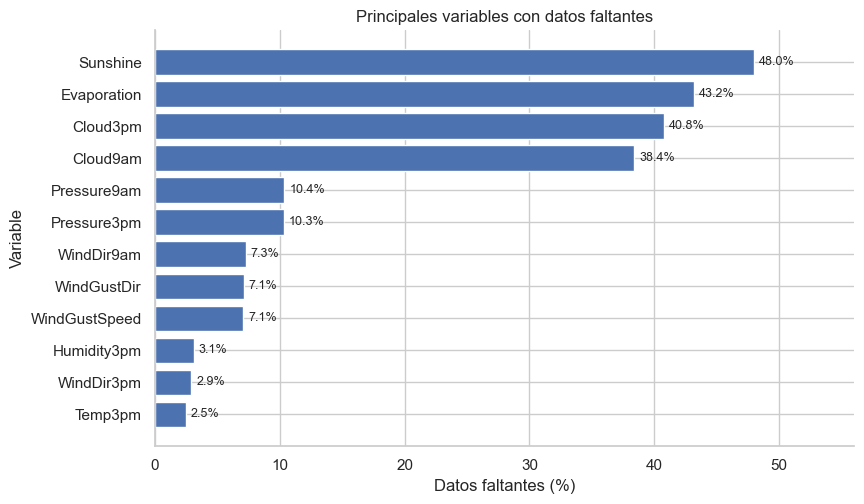

In [5]:
missing_table = (
    df.isna()
    .sum()
    .rename("n_faltantes")
    .reset_index()
    .rename(columns={"index": "variable"})
)
missing_table["porcentaje_faltantes"] = (
    missing_table["n_faltantes"] / len(df) * 100
)
missing_table = missing_table.sort_values("porcentaje_faltantes", ascending=False)
missing_table.to_csv(
    tables_dir / "03_auditoria_datos_faltantes.csv",
    index=False,
    encoding="utf-8-sig",
)

display(missing_table.head(12).round(2))

fig, ax = plt.subplots(figsize=(8.8, 5.2))
plot_data = missing_table.head(12).sort_values("porcentaje_faltantes")
ax.barh(plot_data["variable"], plot_data["porcentaje_faltantes"])
ax.set_xlabel("Datos faltantes (%)")
ax.set_ylabel("Variable")
ax.set_title("Principales variables con datos faltantes")
for i, value in enumerate(plot_data["porcentaje_faltantes"]):
    ax.text(value + 0.4, i, f"{value:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, max(plot_data["porcentaje_faltantes"]) + 8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(figures_dir / "fig_01_datos_faltantes.png", dpi=300, bbox_inches="tight")
plt.show()


### Justificación metodológica sobre datos faltantes

El dataset presenta omisiones naturales en variables meteorológicas como `Evaporation`, `Sunshine`, `Cloud9am` y `Cloud3pm`. Estas ausencias son coherentes con limitaciones operacionales de medición, diferencias entre estaciones meteorológicas y disponibilidad parcial de ciertos instrumentos.

Para este análisis no se generan datos faltantes artificiales bajo un mecanismo MCAR, ya que la base seleccionada contiene datos faltantes reales en varias variables. Esta decisión evita modificar artificialmente la estructura original del dataset y mantiene la trazabilidad del análisis exploratorio.


### Preparación de la base para el análisis

El análisis se desarrolló sobre una copia del dataset original, manteniendo la base inicial sin modificaciones directas. A partir de esta copia se generan variables de apoyo para facilitar la interpretación estadística, tales como la codificación binaria de `RainToday` y `RainTomorrow`, además de variables temporales derivadas de la fecha, como año, mes y estación del año. Dado que esta etapa corresponde a un análisis exploratorio, descriptivo e inferencial, no se aplica una imputación general de valores faltantes ni una eliminación masiva de registros. Los valores nulos se tratan de forma puntual en cada análisis, considerando únicamente las observaciones válidas para las variables utilizadas en cada gráfico, estimación o prueba estadística.


## Fase 2: Aplicación de estadística descriptiva

En esta fase se clasifican las variables según su tipo estadístico y rol analítico, se calculan métricas descriptivas para variables meteorológicas clave y se complementa el análisis mediante una matriz de correlación de Pearson. También se presentan visualizaciones para evaluar distribución, dispersión y comportamiento por grupo de `RainTomorrow`.


In [6]:
clasificacion_manual = {
    "Date": ("temporal", "fecha", "identificación temporal", "Fecha de observación"),
    "Location": ("categórica", "nominal", "agrupación geográfica", "Estación o localidad meteorológica"),
    "MinTemp": ("numérica", "continua", "predictora", "Temperatura mínima diaria"),
    "MaxTemp": ("numérica", "continua", "predictora", "Temperatura máxima diaria"),
    "Rainfall": ("numérica", "continua", "predictora", "Precipitación registrada en el día actual"),
    "Evaporation": ("numérica", "continua", "predictora", "Evaporación registrada"),
    "Sunshine": ("numérica", "continua", "predictora", "Horas de sol"),
    "WindGustDir": ("categórica", "nominal", "predictora", "Dirección de ráfaga máxima"),
    "WindGustSpeed": ("numérica", "continua", "predictora", "Velocidad de ráfaga máxima"),
    "WindDir9am": ("categórica", "nominal", "predictora", "Dirección del viento a las 09:00"),
    "WindDir3pm": ("categórica", "nominal", "predictora", "Dirección del viento a las 15:00"),
    "WindSpeed9am": ("numérica", "continua", "predictora", "Velocidad del viento a las 09:00"),
    "WindSpeed3pm": ("numérica", "continua", "predictora", "Velocidad del viento a las 15:00"),
    "Humidity9am": ("numérica", "continua", "predictora", "Humedad relativa a las 09:00"),
    "Humidity3pm": ("numérica", "continua", "predictora principal", "Humedad relativa a las 15:00"),
    "Pressure9am": ("numérica", "continua", "predictora", "Presión atmosférica a las 09:00"),
    "Pressure3pm": ("numérica", "continua", "predictora", "Presión atmosférica a las 15:00"),
    "Cloud9am": ("numérica", "discreta/ordinal", "predictora", "Nubosidad a las 09:00"),
    "Cloud3pm": ("numérica", "discreta/ordinal", "predictora", "Nubosidad a las 15:00"),
    "Temp9am": ("numérica", "continua", "predictora", "Temperatura a las 09:00"),
    "Temp3pm": ("numérica", "continua", "predictora", "Temperatura a las 15:00"),
    "RainToday": ("categórica", "binaria nominal", "predictora", "Lluvia registrada en el día actual"),
    "RainTomorrow": ("categórica", "binaria nominal", "variable objetivo", "Lluvia registrada al día siguiente"),
    "RainToday_bin": ("numérica", "binaria codificada", "predictora", "Codificación 0/1 de RainToday"),
    "RainTomorrow_bin": ("numérica", "binaria codificada", "variable objetivo codificada", "Codificación 0/1 de RainTomorrow"),
    "Year": ("numérica", "discreta temporal", "variable derivada", "Año de observación"),
    "Month": ("numérica", "discreta temporal", "variable derivada", "Mes de observación"),
    "Season": ("categórica", "nominal temporal", "variable derivada", "Estación climática australiana"),
}

clasificacion_variables = pd.DataFrame(
    [
        {
            "variable": variable,
            "tipo_general": clasificacion_manual.get(variable, ("sin clasificar", "sin clasificar", "sin clasificar", ""))[0],
            "tipo_estadistico": clasificacion_manual.get(variable, ("sin clasificar", "sin clasificar", "sin clasificar", ""))[1],
            "rol_analitico": clasificacion_manual.get(variable, ("sin clasificar", "sin clasificar", "sin clasificar", ""))[2],
            "descripcion": clasificacion_manual.get(variable, ("sin clasificar", "sin clasificar", "sin clasificar", ""))[3],
            "n_no_nulos": int(df[variable].notna().sum()),
            "n_faltantes": int(df[variable].isna().sum()),
            "porcentaje_faltantes": df[variable].isna().mean() * 100,
        }
        for variable in df.columns
    ]
)

resumen_clasificacion = (
    clasificacion_variables
    .groupby(["tipo_general", "tipo_estadistico", "rol_analitico"], dropna=False)
    .size()
    .reset_index(name="cantidad_variables")
)

clasificacion_variables.to_csv(
    tables_dir / "04_clasificacion_detallada_variables.csv",
    index=False,
    encoding="utf-8-sig",
)
resumen_clasificacion.to_csv(
    tables_dir / "04b_resumen_clasificacion_variables.csv",
    index=False,
    encoding="utf-8-sig",
)

display(clasificacion_variables.round({"porcentaje_faltantes": 2}))
display(resumen_clasificacion)


,variable,tipo_general,tipo_estadistico,rol_analitico,descripcion,n_no_nulos,n_faltantes,porcentaje_faltantes
0,Date,temporal,fecha,identificación temporal,Fecha de observación,145460,0,0.0000
1,Location,categórica,nominal,agrupación geográfica,Estación o localidad meteorológica,145460,0,0.0000
2,MinTemp,numérica,continua,predictora,Temperatura mínima diaria,143975,1485,1.0200
3,MaxTemp,numérica,continua,predictora,Temperatura máxima diaria,144199,1261,0.8700
4,Rainfall,numérica,continua,predictora,Precipitación registrada en el día actual,142199,3261,2.2400
5,Evaporation,numérica,continua,predictora,Evaporación registrada,82670,62790,43.1700
6,Sunshine,numérica,continua,predictora,Horas de sol,75625,69835,48.0100
7,WindGustDir,categórica,nominal,predictora,Dirección de ráfaga máxima,135134,10326,7.1000
8,WindGustSpeed,numérica,continua,predictora,Velocidad de ráfaga máxima,135197,10263,7.0600
9,WindDir9am,categórica,nominal,predictora,Dirección del viento a las 09:00,134894,10566,7.2600


,tipo_general,tipo_estadistico,rol_analitico,cantidad_variables
0,categórica,binaria nominal,predictora,1
1,categórica,binaria nominal,variable objetivo,1
2,categórica,nominal,agrupación geográfica,1
3,categórica,nominal,predictora,3
4,categórica,nominal temporal,variable derivada,1
5,numérica,binaria codificada,predictora,1
6,numérica,binaria codificada,variable objetivo codificada,1
7,numérica,continua,predictora,13
8,numérica,continua,predictora principal,1
9,numérica,discreta temporal,variable derivada,2


In [7]:
variables_clave = ["MinTemp", "MaxTemp", "Humidity3pm", "Pressure3pm"]

descriptive_table = df[variables_clave].agg(
    ["count", "mean", "median", "std", "var", "min", "max"]
).T

q1 = df[variables_clave].quantile(0.25)
q3 = df[variables_clave].quantile(0.75)

descriptive_table["q1"] = q1
descriptive_table["q3"] = q3
descriptive_table["iqr"] = q3 - q1
descriptive_table["skewness"] = df[variables_clave].skew(numeric_only=True)
descriptive_table["kurtosis_exceso"] = df[variables_clave].kurt(numeric_only=True)
descriptive_table["missing_pct"] = df[variables_clave].isna().mean() * 100

descriptive_table = descriptive_table[
    [
        "count",
        "missing_pct",
        "mean",
        "median",
        "std",
        "var",
        "q1",
        "q3",
        "iqr",
        "skewness",
        "kurtosis_exceso",
        "min",
        "max",
    ]
]

descriptive_export = descriptive_table.round(3).reset_index().rename(columns={"index": "variable"})
descriptive_export.to_csv(
    tables_dir / "05_estadistica_descriptiva_variables_clave.csv",
    index=False,
    encoding="utf-8-sig",
)

display(descriptive_export)


,variable,count,missing_pct,mean,median,std,var,q1,q3,iqr,skewness,kurtosis_exceso,min,max
0,MinTemp,"143,975.0000",1.0210,12.1940,12.0000,6.3980,40.9410,7.6000,16.9000,9.3000,0.0210,-0.4840,-8.5000,33.9000
1,MaxTemp,"144,199.0000",0.8670,23.2210,22.6000,7.1190,50.6810,17.9000,28.2000,10.3000,0.2210,-0.2250,-4.8000,48.1000
2,Humidity3pm,"140,953.0000",3.0980,51.5390,52.0000,20.7960,432.4700,37.0000,66.0000,29.0000,0.0340,-0.5110,0.0000,100.0000
3,Pressure3pm,"130,432.0000",10.3310,"1,015.2560","1,015.2000",7.0370,49.5250,"1,010.4000","1,020.0000",9.6000,-0.0460,0.1290,977.1000,"1,039.6000"


### Interpretación de asimetría y curtosis

La tabla descriptiva no solo resume medidas de tendencia central y dispersión, sino que también cuantifica la forma de las distribuciones mediante asimetría y curtosis en exceso. La **asimetría** permite evaluar si la distribución se concentra hacia valores bajos o altos respecto de la media; valores cercanos a cero sugieren mayor simetría, valores positivos indican cola hacia la derecha y valores negativos indican cola hacia la izquierda.

La **curtosis en exceso** permite comparar la concentración y el peso relativo de las colas respecto de una distribución normal teórica. Valores cercanos a cero son compatibles con una forma mesocúrtica; valores positivos sugieren colas más pesadas o mayor concentración central, mientras que valores negativos indican distribuciones más aplanadas.

En este análisis, estos indicadores complementan la lectura visual de histogramas, KDE y boxplots, evitando que la forma de las variables sea descrita únicamente de manera cualitativa. Por lo tanto, la interpretación de `MinTemp`, `MaxTemp`, `Humidity3pm` y `Pressure3pm` debe realizarse combinando media, mediana, IQR, asimetría, curtosis y presencia de valores extremos.


### Matriz de correlación de variables meteorológicas

Para complementar la estadística descriptiva univariada, se calcula una matriz de correlación de Pearson entre variables meteorológicas seleccionadas. También se incorporan `RainToday_bin` y `RainTomorrow_bin`, codificadas como 0 = No y 1 = Yes. En estos casos, la correlación con variables continuas se interpreta como una asociación lineal exploratoria de tipo punto-biserial.

Este análisis permite identificar relaciones iniciales entre temperatura, humedad, presión, viento y ocurrencia de lluvia, sin asumir causalidad entre las variables.

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday_bin,RainTomorrow_bin
MinTemp,1.0000,0.7370,0.1040,0.1770,-0.2330,0.0060,-0.4510,-0.4610,0.9020,0.7090,0.0560,0.0840
MaxTemp,0.7370,1.0000,-0.0750,0.0680,-0.5040,-0.5090,-0.3320,-0.4270,0.8870,0.9850,-0.2290,-0.1590
Rainfall,0.1040,-0.0750,1.0000,0.1340,0.2240,0.2560,-0.1680,-0.1270,0.0110,-0.0800,0.5020,0.2390
WindGustSpeed,0.1770,0.0680,0.1340,1.0000,-0.2150,-0.0260,-0.4590,-0.4140,0.1500,0.0330,0.1560,0.2340
Humidity9am,-0.2330,-0.5040,0.2240,-0.2150,1.0000,0.6670,0.1390,0.1870,-0.4710,-0.4980,0.3540,0.2570
Humidity3pm,0.0060,-0.5090,0.2560,-0.0260,0.6670,1.0000,-0.0280,0.0520,-0.2210,-0.5580,0.3790,0.4460
Pressure9am,-0.4510,-0.3320,-0.1680,-0.4590,0.1390,-0.0280,1.0000,0.9610,-0.4230,-0.2870,-0.1900,-0.2460
Pressure3pm,-0.4610,-0.4270,-0.1270,-0.4140,0.1870,0.0520,0.9610,1.0000,-0.4700,-0.3900,-0.1060,-0.2260
Temp9am,0.9020,0.8870,0.0110,0.1500,-0.4710,-0.2210,-0.4230,-0.4700,1.0000,0.8610,-0.0970,-0.0260
Temp3pm,0.7090,0.9850,-0.0800,0.0330,-0.4980,-0.5580,-0.2870,-0.3900,0.8610,1.0000,-0.2350,-0.1920


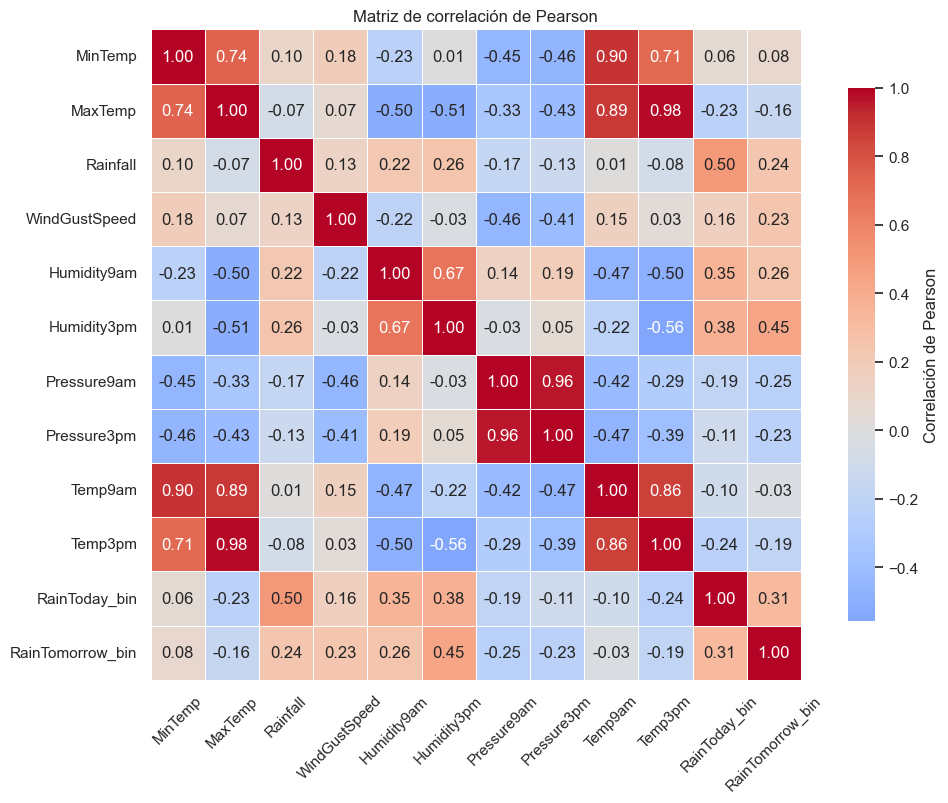

In [8]:
correlation_vars = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "WindGustSpeed",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Temp9am",
    "Temp3pm",
    "RainToday_bin",
    "RainTomorrow_bin",
]

correlation_vars = [variable for variable in correlation_vars if variable in df.columns]
correlation_matrix = df[correlation_vars].corr(method="pearson")

correlation_export = (
    correlation_matrix
    .round(3)
    .reset_index()
    .rename(columns={"index": "variable"})
)

correlation_export.to_csv(
    tables_dir / "06_matriz_correlacion_pearson.csv",
    index=False,
    encoding="utf-8-sig",
)

display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(10.8, 8.2))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    square=True,
    cbar_kws={"shrink": 0.82, "label": "Correlación de Pearson"},
    ax=ax,
)
ax.set_title("Matriz de correlación de Pearson")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(
    figures_dir / "fig_03_matriz_correlacion_pearson.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


La matriz de correlación evidencia relaciones esperadas entre variables meteorológicas. Destaca la alta asociación positiva entre temperaturas medidas en distintos horarios, como `MaxTemp` y `Temp3pm`, además de la relación directa entre `Humidity9am` y `Humidity3pm`. Respecto de `RainTomorrow_bin`, la asociación lineal más relevante dentro de las variables seleccionadas se observa con `Humidity3pm`, lo que respalda su uso posterior en la estimación de intervalos de confianza y en la prueba de hipótesis principal.

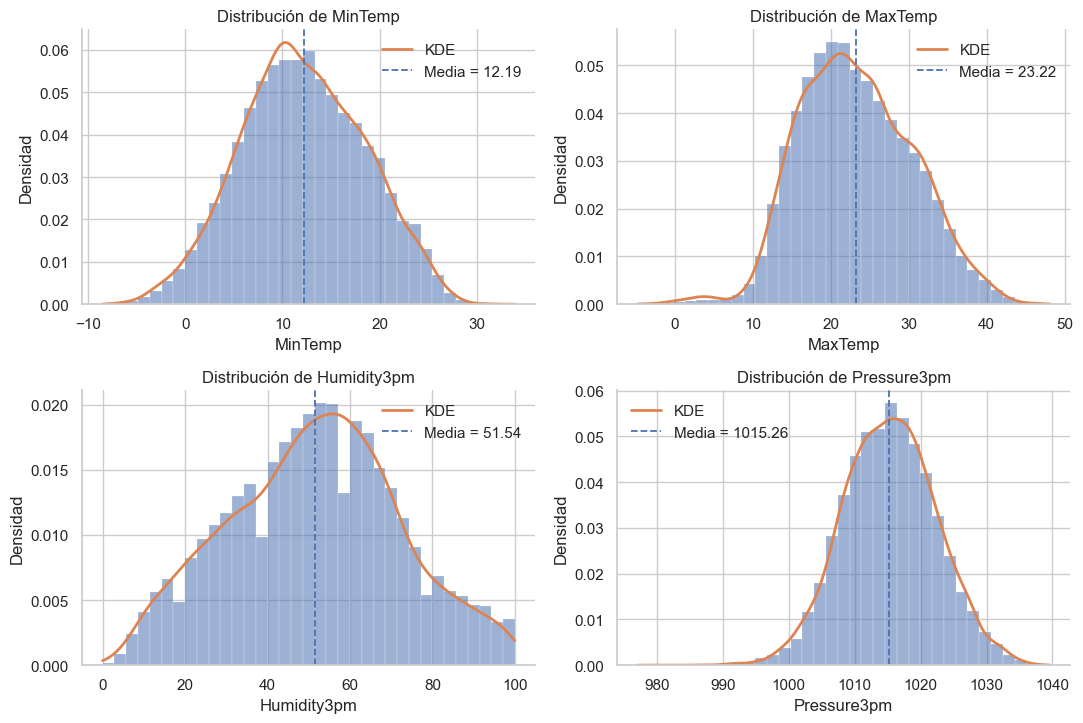

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.4))
axes = axes.ravel()

for ax, variable in zip(axes, variables_clave):
    serie = df[variable].dropna().astype(float)
    ax.hist(
        serie,
        bins=35,
        density=True,
        alpha=0.55,
        edgecolor="white",
        linewidth=0.3,
    )

    kde_serie = serie.sample(n=min(5000, len(serie)), random_state=42)
    x_grid = np.linspace(serie.min(), serie.max(), 400)
    kde = stats.gaussian_kde(kde_serie)
    ax.plot(x_grid, kde(x_grid), linewidth=2.0, label="KDE")
    ax.axvline(
        serie.mean(),
        linestyle="--",
        linewidth=1.3,
        label=f"Media = {serie.mean():.2f}",
    )
    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Densidad")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    figures_dir / "fig_02_histogramas_kde_variables_clave.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


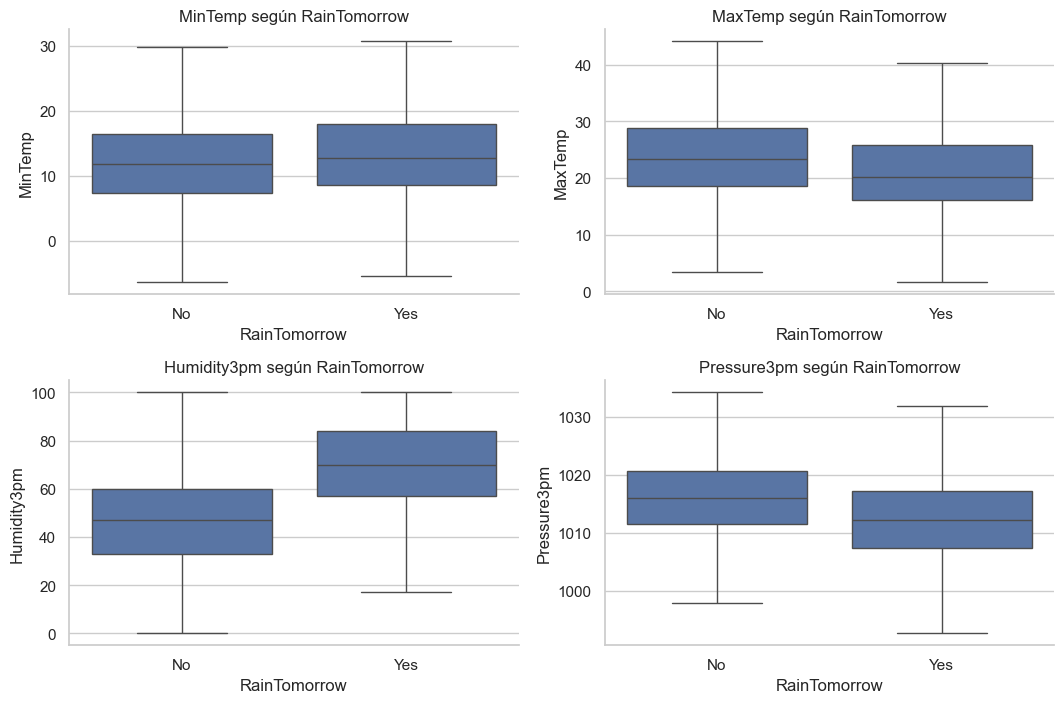

In [10]:
boxplot_data = df.dropna(subset=["RainTomorrow"]).copy()

fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.2))
axes = axes.ravel()

for ax, variable in zip(axes, variables_clave):
    sns.boxplot(
        data=boxplot_data,
        x="RainTomorrow",
        y=variable,
        order=["No", "Yes"],
        showfliers=False,
        ax=ax,
    )
    ax.set_title(f"{variable} según RainTomorrow")
    ax.set_xlabel("RainTomorrow")
    ax.set_ylabel(variable)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_dir / "fig_04_boxplots_por_rain_tomorrow.png", dpi=300, bbox_inches="tight")
plt.show()


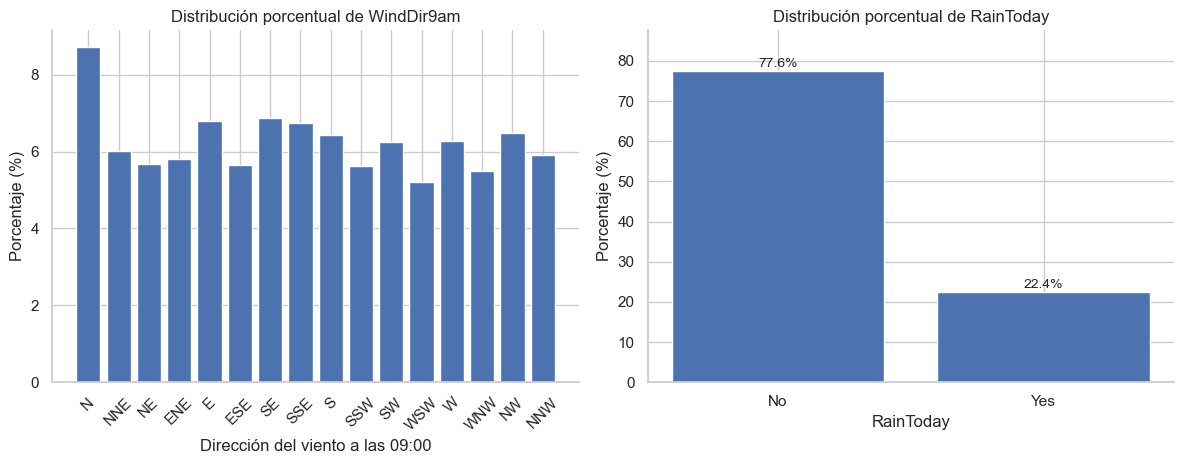

In [11]:
wind_order = [
    "N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW",
]

wind_counts = (
    df["WindDir9am"]
    .dropna()
    .value_counts()
    .reindex(wind_order)
    .dropna()
)

rain_today_counts = df["RainToday"].dropna().value_counts().reindex(["No", "Yes"])

wind_export = wind_counts.rename_axis("WindDir9am").reset_index(name="frecuencia")
wind_export["porcentaje"] = wind_export["frecuencia"] / wind_export["frecuencia"].sum() * 100
wind_export.to_csv(tables_dir / "07_frecuencia_winddir9am.csv", index=False, encoding="utf-8-sig")

rain_today_export = rain_today_counts.rename_axis("RainToday").reset_index(name="frecuencia")
rain_today_export["porcentaje"] = rain_today_export["frecuencia"] / rain_today_export["frecuencia"].sum() * 100
rain_today_export.to_csv(tables_dir / "08_frecuencia_rain_today.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].bar(wind_export["WindDir9am"], wind_export["porcentaje"])
axes[0].set_title("Distribución porcentual de WindDir9am")
axes[0].set_xlabel("Dirección del viento a las 09:00")
axes[0].set_ylabel("Porcentaje (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].bar(rain_today_export["RainToday"], rain_today_export["porcentaje"])
axes[1].set_title("Distribución porcentual de RainToday")
axes[1].set_xlabel("RainToday")
axes[1].set_ylabel("Porcentaje (%)")
for i, value in enumerate(rain_today_export["porcentaje"]):
    axes[1].text(i, value + 1, f"{value:.1f}%", ha="center", fontsize=10)
axes[1].set_ylim(0, max(rain_today_export["porcentaje"]) + 10)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_dir / "fig_05_barras_winddir9am_raintoday.png", dpi=300, bbox_inches="tight")
plt.show()


,RainTomorrow,frecuencia,porcentaje
0,No,110316,77.5800
1,Yes,31877,22.4200


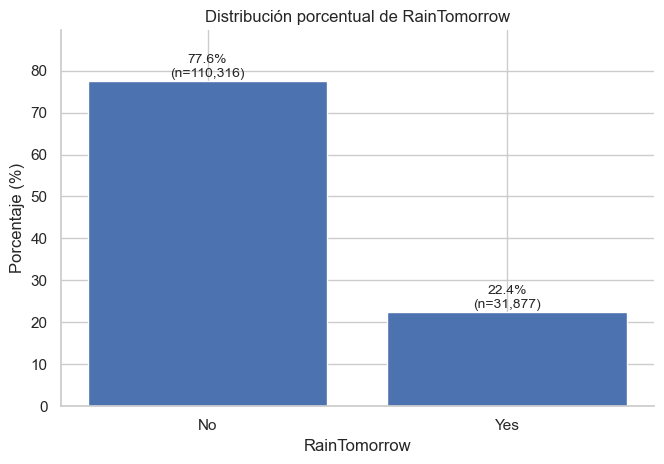

In [12]:
rain_counts = df["RainTomorrow"].dropna().value_counts().reindex(["No", "Yes"])
rain_freq = rain_counts.rename_axis("RainTomorrow").reset_index(name="frecuencia")
rain_freq["porcentaje"] = rain_freq["frecuencia"] / rain_freq["frecuencia"].sum() * 100
rain_freq.to_csv(tables_dir / "09_frecuencia_rain_tomorrow.csv", index=False, encoding="utf-8-sig")

display(rain_freq.round(2))

fig, ax = plt.subplots(figsize=(6.8, 4.8))
ax.bar(rain_freq["RainTomorrow"], rain_freq["porcentaje"])
ax.set_xlabel("RainTomorrow")
ax.set_ylabel("Porcentaje (%)")
ax.set_title("Distribución porcentual de RainTomorrow")
for i, row in rain_freq.iterrows():
    ax.text(
        i,
        row["porcentaje"] + 1,
        f'{row["porcentaje"]:.1f}%\n(n={int(row["frecuencia"]):,})',
        ha="center",
        fontsize=10,
    )
ax.set_ylim(0, max(rain_freq["porcentaje"]) + 12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(figures_dir / "fig_06_distribucion_rain_tomorrow.png", dpi=300, bbox_inches="tight")
plt.show()


## Fase 3: Estimación puntual e intervalos de confianza

Se selecciona `Humidity3pm` por su relación física directa con la formación de precipitación: una mayor humedad relativa durante la tarde indica una atmósfera con mayor contenido de vapor de agua disponible. Se estima la media muestral y se construyen intervalos de confianza al 95% y 99%.


In [13]:
humidity3pm = df["Humidity3pm"].dropna()

ic_humidity_global = pd.DataFrame(
    [
        {"variable": "Humidity3pm", "confianza": "95%", **media_ic_t(humidity3pm, confianza=0.95)},
        {"variable": "Humidity3pm", "confianza": "99%", **media_ic_t(humidity3pm, confianza=0.99)},
    ]
)

ic_humidity_global.to_csv(
    tables_dir / "10_ic_humidity3pm_95_99.csv",
    index=False,
    encoding="utf-8-sig",
)

display(ic_humidity_global.round(4))


,variable,confianza,n,media,sd,se,ic_inf,ic_sup
0,Humidity3pm,95%,140953,51.5391,20.7959,0.0554,51.4306,51.6477
1,Humidity3pm,99%,140953,51.5391,20.7959,0.0554,51.3964,51.6818


,RainTomorrow,confianza,n,media,sd,se,ic_inf,ic_sup
0,No,95%,107670,46.5110,18.4890,0.0560,46.4000,46.6210
1,No,99%,107670,46.5110,18.4890,0.0560,46.3650,46.6560
2,Yes,95%,30913,68.8000,19.0370,0.1080,68.5880,69.0120
3,Yes,99%,30913,68.8000,19.0370,0.1080,68.5210,69.0790


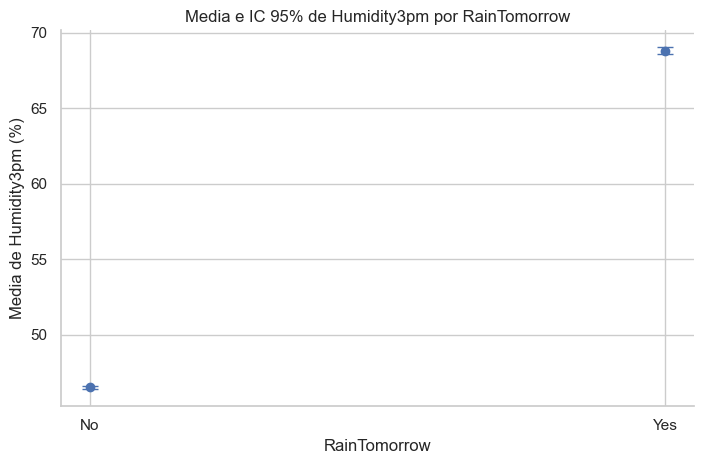

In [14]:
ic_humidity_group = []

for label, val in [("No", 0), ("Yes", 1)]:
    for confidence in [0.95, 0.99]:
        result = media_ic_t(
            df.loc[df["RainTomorrow_bin"].eq(val), "Humidity3pm"],
            confianza=confidence,
        )
        result["RainTomorrow"] = label
        result["confianza"] = f"{int(confidence * 100)}%"
        ic_humidity_group.append(result)

ic_humidity_group = pd.DataFrame(ic_humidity_group)[
    ["RainTomorrow", "confianza", "n", "media", "sd", "se", "ic_inf", "ic_sup"]
]

ic_humidity_group.to_csv(
    tables_dir / "11_ic_humidity3pm_por_grupo_95_99.csv",
    index=False,
    encoding="utf-8-sig",
)

display(ic_humidity_group.round(3))

ic95_group = ic_humidity_group.query("confianza == '95%'").copy()

fig, ax = plt.subplots(figsize=(7.2, 4.8))
x_pos = np.arange(len(ic95_group))
yerr = [
    ic95_group["media"] - ic95_group["ic_inf"],
    ic95_group["ic_sup"] - ic95_group["media"],
]
ax.errorbar(
    x_pos,
    ic95_group["media"],
    yerr=yerr,
    fmt="o",
    capsize=6,
    linewidth=1.8,
    markersize=6,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(ic95_group["RainTomorrow"])
ax.set_xlabel("RainTomorrow")
ax.set_ylabel("Media de Humidity3pm (%)")
ax.set_title("Media e IC 95% de Humidity3pm por RainTomorrow")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(figures_dir / "fig_07_ic95_humidity3pm_por_grupo.png", dpi=300, bbox_inches="tight")
plt.show()


### Estimación de proporción mediante Wilson

Además de estimar la media de `Humidity3pm`, se estima la proporción de observaciones con `RainTomorrow = Yes`. Para esta variable binaria se utilizó el intervalo de Wilson, debido a que permite entregar una aproximación más estable para proporciones que el intervalo normal simple.


In [15]:
rain_tomorrow_valid = df["RainTomorrow_bin"].dropna().astype(int)
n_rain_tomorrow = int(rain_tomorrow_valid.count())
x_rain_tomorrow = int(rain_tomorrow_valid.sum())

wilson_rows = []
for confidence in [0.95, 0.99]:
    wilson_result = proporcion_ic_wilson(
        x_rain_tomorrow,
        n_rain_tomorrow,
        confianza=confidence,
    )
    wilson_result["variable"] = "RainTomorrow"
    wilson_result["evento"] = "Yes"
    wilson_result["confianza"] = f"{int(confidence * 100)}%"
    wilson_rows.append(wilson_result)

ic_rain_tomorrow_wilson = pd.DataFrame(wilson_rows)

ic_rain_tomorrow_wilson["porcentaje"] = ic_rain_tomorrow_wilson["proporcion"] * 100
ic_rain_tomorrow_wilson["ic_inf_pct"] = ic_rain_tomorrow_wilson["ic_inf"] * 100
ic_rain_tomorrow_wilson["ic_sup_pct"] = ic_rain_tomorrow_wilson["ic_sup"] * 100

ic_rain_tomorrow_wilson = ic_rain_tomorrow_wilson[
    [
        "variable",
        "evento",
        "confianza",
        "n",
        "exitos",
        "proporcion",
        "porcentaje",
        "ic_inf",
        "ic_sup",
        "ic_inf_pct",
        "ic_sup_pct",
    ]
]

ic_rain_tomorrow_wilson.to_csv(
    tables_dir / "12_ic_wilson_proporcion_rain_tomorrow_yes.csv",
    index=False,
    encoding="utf-8-sig",
)

display(ic_rain_tomorrow_wilson.round(4))


,variable,evento,confianza,n,exitos,proporcion,porcentaje,ic_inf,ic_sup,ic_inf_pct,ic_sup_pct
0,RainTomorrow,Yes,95%,142193,31877,0.2242,22.4181,0.2220,0.2264,22.2021,22.6356
1,RainTomorrow,Yes,99%,142193,31877,0.2242,22.4181,0.2213,0.2270,22.1345,22.7043


### Interpretación de los intervalos de confianza

La media muestral de `Humidity3pm` representa una estimación del nivel promedio de humedad relativa registrado a las 15:00 horas en el conjunto de observaciones analizadas. El intervalo de confianza al 95% entrega un rango plausible para la media poblacional bajo el procedimiento de muestreo utilizado, mientras que el intervalo al 99% presenta una amplitud mayor por incorporar un nivel de confianza más exigente.

La interpretación se plantea desde el enfoque frecuentista: si el procedimiento de muestreo y estimación se repitiera muchas veces en condiciones equivalentes, aproximadamente el 95% o 99% de los intervalos construidos de esa forma contendría el verdadero parámetro poblacional. Por lo tanto, no corresponde afirmar que el parámetro queda contenido con certeza absoluta en el intervalo calculado para esta muestra específica.

En el caso de `RainTomorrow`, la estimación de proporción mediante Wilson permite cuantificar la frecuencia relativa de días con lluvia al día siguiente y entregar un intervalo de confianza apropiado para una variable binaria.


## Fase 4: Aplicación de pruebas de hipótesis

Se evalúa si la humedad promedio a las 15:00 es mayor en los días asociados a lluvia al día siguiente. La comparación se formula como una prueba t para dos muestras independientes. Dado que los tamaños muestrales y varianzas pueden diferir entre grupos, se utiliza la variante de Welch mediante `scipy.stats.ttest_ind` con `equal_var=False`.

La hipótesis nula establece que la media de `Humidity3pm` para `RainTomorrow = Yes` es igual a la media de `Humidity3pm` para `RainTomorrow = No`. La hipótesis alternativa plantea que la media de `Humidity3pm` para `RainTomorrow = Yes` es mayor que la media de `Humidity3pm` para `RainTomorrow = No`. La prueba se desarrolla con un nivel de significancia α = 0,05 y sentido unilateral a la derecha.


In [16]:
hum_no = df.loc[df["RainTomorrow_bin"].eq(0), "Humidity3pm"].dropna()
hum_yes = df.loc[df["RainTomorrow_bin"].eq(1), "Humidity3pm"].dropna()

welch_res = stats.ttest_ind(
    hum_yes,
    hum_no,
    equal_var=False,
    alternative="greater",
)

s_yes = hum_yes.var(ddof=1)
s_no = hum_no.var(ddof=1)
n_yes = len(hum_yes)
n_no = len(hum_no)

se_diff = np.sqrt(s_yes / n_yes + s_no / n_no)
df_welch = (s_yes / n_yes + s_no / n_no) ** 2 / (
    (s_yes / n_yes) ** 2 / (n_yes - 1) + (s_no / n_no) ** 2 / (n_no - 1)
)

mean_diff = hum_yes.mean() - hum_no.mean()
tcrit = stats.t.ppf(0.975, df_welch)
cohen_d = cohens_d_independiente(hum_yes, hum_no)

welch_table = pd.DataFrame(
    [
        {
            "n_lluvia": n_yes,
            "n_sin_lluvia": n_no,
            "media_lluvia": hum_yes.mean(),
            "media_sin_lluvia": hum_no.mean(),
            "diferencia_medias": mean_diff,
            "ic95_inf_diferencia": mean_diff - tcrit * se_diff,
            "ic95_sup_diferencia": mean_diff + tcrit * se_diff,
            "t": welch_res.statistic,
            "gl_welch": df_welch,
            "p_valor_unilateral": welch_res.pvalue,
            "p_valor_reporte": "< 0.001" if welch_res.pvalue < 0.001 else f"{welch_res.pvalue:.4f}",
            "cohen_d": cohen_d,
            "decision_alpha_0_05": "Rechazar H0"
            if welch_res.pvalue < 0.05
            else "No rechazar H0",
        }
    ]
)

welch_table.to_csv(
    tables_dir / "13_prueba_t_welch_humidity3pm_unilateral.csv",
    index=False,
    encoding="utf-8-sig",
)

display(welch_table.round(4))


,n_lluvia,n_sin_lluvia,media_lluvia,media_sin_lluvia,diferencia_medias,ic95_inf_diferencia,ic95_sup_diferencia,t,gl_welch,p_valor_unilateral,p_valor_reporte,cohen_d,decision_alpha_0_05
0,30913,107670,68.8000,46.5106,22.2894,22.0502,22.5286,182.6077,"48,892.7962",0.0000,< 0.001,1.1975,Rechazar H0


### Nota sobre el intervalo de confianza de la diferencia de medias

La prueba t de Welch se formula como **unilateral a la derecha**, porque la hipótesis alternativa plantea que la media de `Humidity3pm` en `RainTomorrow = Yes` es mayor que en `RainTomorrow = No`. En cambio, el intervalo reportado para la diferencia de medias corresponde a un **intervalo bilateral del 95%**, utilizado para cuantificar el rango plausible de la magnitud de la diferencia observada. Esta distinción evita confundir la lógica decisional de la prueba con la estimación de tamaño del efecto.


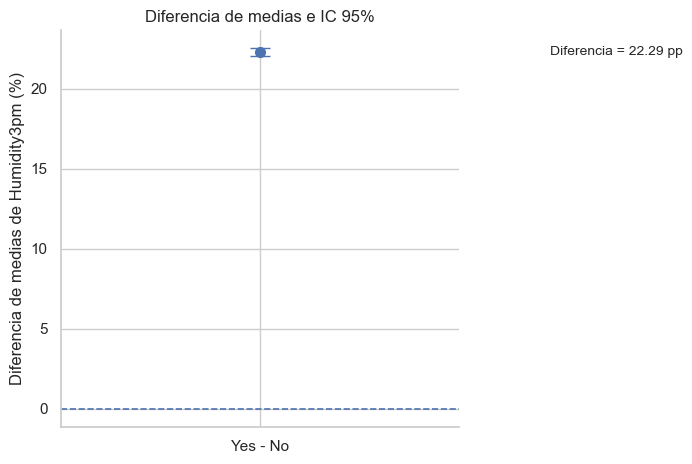

In [17]:
diff_info = welch_table.iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.errorbar(
    x=[0],
    y=[diff_info["diferencia_medias"]],
    yerr=[
        [
            diff_info["diferencia_medias"] - diff_info["ic95_inf_diferencia"],
        ],
        [
            diff_info["ic95_sup_diferencia"] - diff_info["diferencia_medias"],
        ],
    ],
    fmt="o",
    capsize=7,
    linewidth=2,
    markersize=7,
)
ax.axhline(0, linestyle="--", linewidth=1.2)
ax.set_xticks([0])
ax.set_xticklabels(["Yes - No"])
ax.set_ylabel("Diferencia de medias de Humidity3pm (%)")
ax.set_title("Diferencia de medias e IC 95%")
ax.text(
    0.08,
    diff_info["diferencia_medias"],
    f'Diferencia = {diff_info["diferencia_medias"]:.2f} pp',
    va="center",
    fontsize=10,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(figures_dir / "fig_08_diferencia_medias_humidity3pm.png", dpi=300, bbox_inches="tight")
plt.show()


### Poder muestral y sensibilidad del p-value

El dataset dispone de un volumen elevado de observaciones válidas para la variable objetivo, lo que incrementa la potencia estadística de la prueba t. En este contexto, diferencias moderadas o pequeñas entre grupos pueden producir valores p muy bajos. Por ello, la decisión inferencial se interpreta junto con la magnitud observada de la diferencia de medias y el tamaño de efecto estimado mediante `Cohen d`.


### Prueba complementaria: asociación entre `RainToday` y `RainTomorrow`

Como análisis categórico complementario, se aplica una prueba chi-cuadrado de independencia para evaluar si existe asociación estadísticamente significativa entre la ocurrencia de lluvia en el día actual (`RainToday`) y la ocurrencia de lluvia al día siguiente (`RainTomorrow`).

La formulación estadística es la siguiente:

- **H0:** `RainToday` y `RainTomorrow` son variables independientes.
- **H1:** `RainToday` y `RainTomorrow` no son variables independientes; existe asociación estadística entre ambas.

La prueba se desarrolla con nivel de significancia α = 0,05. Además del estadístico χ² y el p-value, se reporta la **V de Cramer** para cuantificar la intensidad de asociación entre ambas variables categóricas.


In [18]:
contingency = pd.crosstab(df["RainToday"], df["RainTomorrow"])
chi2, p_value_chi, dof, expected = chi2_contingency(contingency)
cramer_v = np.sqrt(
    chi2 / (contingency.to_numpy().sum() * (min(contingency.shape) - 1))
)

chi_table = pd.DataFrame(
    [
        {
            "chi2": chi2,
            "gl": dof,
            "p_valor": p_value_chi,
            "p_valor_reporte": "< 0.001" if p_value_chi < 0.001 else f"{p_value_chi:.4f}",
            "cramers_v": cramer_v,
            "n": contingency.to_numpy().sum(),
            "decision_alpha_0_05": "Rechazar H0"
            if p_value_chi < 0.05
            else "No rechazar H0",
        }
    ]
)

contingency.reset_index().to_csv(
    tables_dir / "14_tabla_contingencia_rain_today_rain_tomorrow.csv",
    index=False,
    encoding="utf-8-sig",
)
chi_table.to_csv(
    tables_dir / "15_prueba_chi2_rain_today_rain_tomorrow.csv",
    index=False,
    encoding="utf-8-sig",
)

display(contingency)
display(chi_table.round(4))


RainTomorrow,No,Yes
RainToday,,
No,92728,16604
Yes,16858,14597


,chi2,gl,p_valor,p_valor_reporte,cramers_v,n,decision_alpha_0_05
0,"13,799.4796",1,0.0000,< 0.001,0.3131,140787,Rechazar H0


In [19]:
expected_table = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns,
)

expected_table.to_csv(
    tables_dir / "15b_frecuencias_esperadas_chi2_rain_today_rain_tomorrow.csv",
    index=True,
    encoding="utf-8-sig",
)

display(expected_table.round(2))


RainTomorrow,No,Yes
RainToday,,
No,"85,102.0100","24,229.9900"
Yes,"24,483.9900","6,971.0100"


RainTomorrow,No,Yes
RainToday,,
No,84.8100,15.1900
Yes,53.5900,46.4100


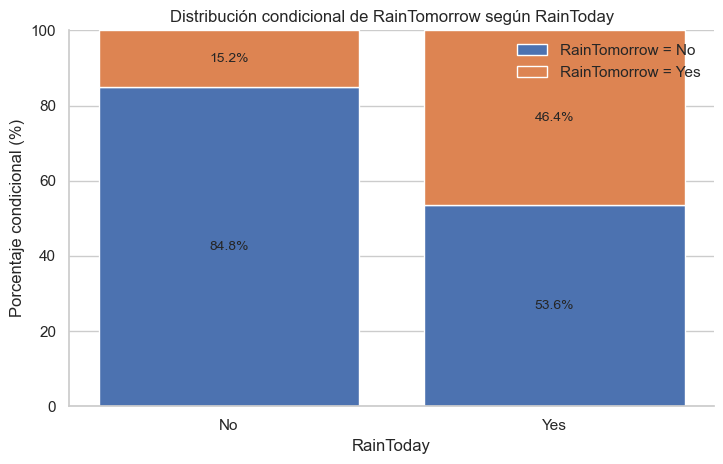

In [20]:
conditional_prob = pd.crosstab(
    df["RainToday"],
    df["RainTomorrow"],
    normalize="index",
) * 100

conditional_prob.reset_index().to_csv(
    tables_dir / "16_probabilidades_condicionales_rain_today.csv",
    index=False,
    encoding="utf-8-sig",
)

display(conditional_prob.round(2))

fig, ax = plt.subplots(figsize=(7.4, 4.8))
bottom = np.zeros(len(conditional_prob))

for column in ["No", "Yes"]:
    values = conditional_prob[column].values
    ax.bar(conditional_prob.index, values, bottom=bottom, label=f"RainTomorrow = {column}")
    for idx, value in enumerate(values):
        ax.text(
            idx,
            bottom[idx] + value / 2,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
        )
    bottom += values

ax.set_ylabel("Porcentaje condicional (%)")
ax.set_xlabel("RainToday")
ax.set_title("Distribución condicional de RainTomorrow según RainToday")
ax.legend(frameon=False, loc="upper right")
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(figures_dir / "fig_09_condicional_rain_today_rain_tomorrow.png", dpi=300, bbox_inches="tight")
plt.show()


### Resultados consolidados para trazabilidad del informe

La tabla consolida los resultados principales del análisis estadístico y señala la fuente exportada correspondiente. Estos valores sirven como referencia directa para poder ser incluidos en el informe técnico con consistencia numérica.


In [21]:
ic_global_95 = ic_humidity_global.query("confianza == '95%'").iloc[0]
ic_global_99 = ic_humidity_global.query("confianza == '99%'").iloc[0]
ic_no_95 = ic_humidity_group.query("RainTomorrow == 'No' and confianza == '95%'").iloc[0]
ic_yes_95 = ic_humidity_group.query("RainTomorrow == 'Yes' and confianza == '95%'").iloc[0]
wilson_95 = ic_rain_tomorrow_wilson.query("confianza == '95%'").iloc[0]
wilson_99 = ic_rain_tomorrow_wilson.query("confianza == '99%'").iloc[0]
welch_info = welch_table.iloc[0]
chi_info = chi_table.iloc[0]

resultados_clave = pd.DataFrame(
    [
        {
            "seccion": "Estimación media",
            "indicador": "Media global Humidity3pm",
            "valor": ic_global_95["media"],
            "detalle": f"IC 95%: {ic_global_95['ic_inf']:.4f} a {ic_global_95['ic_sup']:.4f}; IC 99%: {ic_global_99['ic_inf']:.4f} a {ic_global_99['ic_sup']:.4f}",
            "tabla_fuente": "10_ic_humidity3pm_95_99.csv",
        },
        {
            "seccion": "Estimación media",
            "indicador": "Media Humidity3pm | RainTomorrow = No",
            "valor": ic_no_95["media"],
            "detalle": f"IC 95%: {ic_no_95['ic_inf']:.4f} a {ic_no_95['ic_sup']:.4f}",
            "tabla_fuente": "11_ic_humidity3pm_por_grupo_95_99.csv",
        },
        {
            "seccion": "Estimación media",
            "indicador": "Media Humidity3pm | RainTomorrow = Yes",
            "valor": ic_yes_95["media"],
            "detalle": f"IC 95%: {ic_yes_95['ic_inf']:.4f} a {ic_yes_95['ic_sup']:.4f}",
            "tabla_fuente": "11_ic_humidity3pm_por_grupo_95_99.csv",
        },
        {
            "seccion": "Estimación proporción",
            "indicador": "Proporción RainTomorrow = Yes, Wilson",
            "valor": wilson_95["porcentaje"],
            "detalle": f"IC Wilson 95%: {wilson_95['ic_inf_pct']:.4f}% a {wilson_95['ic_sup_pct']:.4f}%; IC Wilson 99%: {wilson_99['ic_inf_pct']:.4f}% a {wilson_99['ic_sup_pct']:.4f}%",
            "tabla_fuente": "12_ic_wilson_proporcion_rain_tomorrow_yes.csv",
        },
        {
            "seccion": "Prueba t de Welch",
            "indicador": "Diferencia de medias Humidity3pm: Yes - No",
            "valor": welch_info["diferencia_medias"],
            "detalle": f"t = {welch_info['t']:.4f}; p unilateral {welch_info['p_valor_reporte']}; Cohen d = {welch_info['cohen_d']:.4f}",
            "tabla_fuente": "13_prueba_t_welch_humidity3pm_unilateral.csv",
        },
        {
            "seccion": "Chi-cuadrado",
            "indicador": "Asociación RainToday vs RainTomorrow",
            "valor": chi_info["chi2"],
            "detalle": f"gl = {int(chi_info['gl'])}; p {chi_info['p_valor_reporte']}; V de Cramer = {chi_info['cramers_v']:.4f}",
            "tabla_fuente": "15_prueba_chi2_rain_today_rain_tomorrow.csv",
        },
    ]
)

resultados_clave.to_csv(
    tables_dir / "17_resultados_clave_para_informe.csv",
    index=False,
    encoding="utf-8-sig",
)

display(resultados_clave.round(4))


,seccion,indicador,valor,detalle,tabla_fuente
0,Estimación media,Media global Humidity3pm,51.5391,IC 95%: 51.4306 a 51.6477; IC 99%: 51.3964 a 5...,10_ic_humidity3pm_95_99.csv
1,Estimación media,Media Humidity3pm | RainTomorrow = No,46.5106,IC 95%: 46.4002 a 46.6211,11_ic_humidity3pm_por_grupo_95_99.csv
2,Estimación media,Media Humidity3pm | RainTomorrow = Yes,68.8000,IC 95%: 68.5878 a 69.0122,11_ic_humidity3pm_por_grupo_95_99.csv
3,Estimación proporción,"Proporción RainTomorrow = Yes, Wilson",22.4181,IC Wilson 95%: 22.2021% a 22.6356%; IC Wilson ...,12_ic_wilson_proporcion_rain_tomorrow_yes.csv
4,Prueba t de Welch,Diferencia de medias Humidity3pm: Yes - No,22.2894,t = 182.6077; p unilateral < 0.001; Cohen d = ...,13_prueba_t_welch_humidity3pm_unilateral.csv
5,Chi-cuadrado,Asociación RainToday vs RainTomorrow,"13,799.4796",gl = 1; p < 0.001; V de Cramer = 0.3131,15_prueba_chi2_rain_today_rain_tomorrow.csv


## Fase 5: Documentación, exportación y control de trazabilidad de la Sumativa 1

Se exportan tablas, figuras, una base procesada con variables clave y un inventario de resultados para mantener consistencia entre el notebook, el informe técnico de la Sumativa 1 y el repositorio del proyecto. 


In [22]:
analysis_cols = (
    ["Date", "Location", "Year", "Month", "Season"]
    + variables_clave
    + ["Rainfall", "WindDir9am", "RainToday", "RainTomorrow", "RainToday_bin", "RainTomorrow_bin"]
)

df[analysis_cols].to_csv(
    processed_dir / "weatherAUS_sumativa1_variables_clave.csv",
    index=False,
    encoding="utf-8-sig",
)

table_files = sorted(tables_dir.glob("*.csv"))
figure_files = sorted(figures_dir.glob("*.png"))

inventory = pd.DataFrame(
    {
        "tipo": ["tabla"] * len(table_files) + ["figura"] * len(figure_files),
        "archivo": [p.name for p in table_files] + [p.name for p in figure_files],
        "ruta": [p.relative_to(project_root).as_posix() for p in table_files]
        + [p.relative_to(project_root).as_posix() for p in figure_files],
    }
)

inventory.to_csv(
    docs_dir / "inventario_outputs_sumativa1.csv",
    index=False,
    encoding="utf-8-sig",
)

display(inventory)


,tipo,archivo,ruta
0,tabla,01_resumen_base.csv,docs/tables/01_resumen_base.csv
1,tabla,02_tipos_datos.csv,docs/tables/02_tipos_datos.csv
2,tabla,03_auditoria_datos_faltantes.csv,docs/tables/03_auditoria_datos_faltantes.csv
3,tabla,04_clasificacion_detallada_variables.csv,docs/tables/04_clasificacion_detallada_variabl...
4,tabla,04b_resumen_clasificacion_variables.csv,docs/tables/04b_resumen_clasificacion_variable...
5,tabla,05_estadistica_descriptiva_variables_clave.csv,docs/tables/05_estadistica_descriptiva_variabl...
6,tabla,06_matriz_correlacion_pearson.csv,docs/tables/06_matriz_correlacion_pearson.csv
7,tabla,07_frecuencia_winddir9am.csv,docs/tables/07_frecuencia_winddir9am.csv
8,tabla,08_frecuencia_rain_today.csv,docs/tables/08_frecuencia_rain_today.csv
9,tabla,09_frecuencia_rain_tomorrow.csv,docs/tables/09_frecuencia_rain_tomorrow.csv


In [23]:
# Control de calidad de nomenclatura para la Sumativa 1
# Este control verifica que los archivos principales usen la nomenclatura oficial de la entrega.

exported_names = [
    "weatherAUS_sumativa1_variables_clave.csv",
    "inventario_outputs_sumativa1.csv",
]

control_nomenclatura = pd.DataFrame(
    {
        "archivo_esperado": exported_names,
        "contiene_sumativa1": ["sumativa1" in name.lower() for name in exported_names],
        "extension_csv": [name.lower().endswith(".csv") for name in exported_names],
    }
)

display(control_nomenclatura)
assert control_nomenclatura["contiene_sumativa1"].all(), "Existen archivos principales sin nomenclatura sumativa1."
assert control_nomenclatura["extension_csv"].all(), "Los archivos principales deben exportarse en formato CSV."


,archivo_esperado,contiene_sumativa1,extension_csv
0,weatherAUS_sumativa1_variables_clave.csv,True,True
1,inventario_outputs_sumativa1.csv,True,True


## Interpretación técnica y aplicaciones de la Sumativa 1

Los resultados permiten observar que la variable `Humidity3pm` presenta una diferencia clara entre los días en que llueve al día siguiente y aquellos en que no se registra lluvia posterior. En las observaciones válidas, la humedad relativa promedio a las 3 p.m. alcanza un 68,80% cuando `RainTomorrow = Yes`, mientras que en los días con `RainTomorrow = No` el promedio es de 46,51%. Esto representa una diferencia aproximada de 22,29 puntos porcentuales, lo que resulta coherente con el comportamiento meteorológico esperado, ya que una mayor humedad durante la tarde puede asociarse con una mayor disponibilidad de vapor de agua en la atmósfera.

La prueba t de Welch unilateral entrega evidencia estadística para sostener que la media de `Humidity3pm` es mayor en el grupo de días donde se registra lluvia al día siguiente. Este resultado se respalda en el estadístico t = 182,61, el p-value reportado en la tabla de resultados y el tamaño de efecto estimado. Por lo tanto, la diferencia observada no solo es estadísticamente significativa, sino que también tiene relevancia práctica dentro del análisis exploratorio realizado.

De forma complementaria, se estimó la proporción de días en que `RainTomorrow = Yes` mediante el intervalo de Wilson. La proporción estimada fue de 22,42%, con un intervalo de confianza al 95% entre 22,20% y 22,64%, y un intervalo al 99% entre 22,13% y 22,70%. Estos resultados permiten dimensionar la frecuencia relativa de días con lluvia al día siguiente dentro del dataset. No obstante, estos intervalos deben entenderse como estimaciones construidas a partir de un procedimiento estadístico, y no como una certeza absoluta sobre el verdadero valor poblacional.

La matriz de correlación también aporta información relevante, ya que muestra una asociación lineal positiva entre `Humidity3pm` y `RainTomorrow_bin` dentro del conjunto de variables analizadas. Asimismo, la prueba chi-cuadrado aplicada entre `RainToday` y `RainTomorrow` permite evaluar la relación entre dos variables categóricas. El resultado obtenido, χ² = 13.799,48, con 1 grado de libertad y p-value menor a 0,001, muestra evidencia estadística de asociación entre ambas variables. Además, la V de Cramer = 0,3131 sugiere que dicha relación presenta una intensidad moderada.

Desde una mirada aplicada, estos resultados entregan antecedentes iniciales que podrían ser útiles en áreas como agricultura, gestión de recursos hídricos y planificación meteorológica. Sin embargo, deben interpretarse como una primera aproximación descriptiva e inferencial. Esta Sumativa 1 no corresponde todavía a un modelo predictivo final, ya que no incorpora de manera conjunta todas las variables meteorológicas, geográficas y estacionales que podrían influir en la ocurrencia de lluvia al día siguiente.

